# Understand the basics of probabilistic solvers

Probabilistic solvers condition a prior distribution
on satisfying a zero-ODE-residual on a specified grid.


In [1]:
"""Demonstrate how probabilistic solvers work via conditioning on constraints."""

import functools

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from diffeqzoo import backend

from probdiffeq import ivpsolve, probdiffeq, taylor

if not backend.has_been_selected:
    backend.select("jax")  # ivp examples in jax


# Fail this notebook on NaN detection (to catch those in the CI)
jax.config.update("jax_debug_nans", True)

Create an ODE problem.

In [2]:
@jax.jit
def vector_field(y, /, *, t):
    """Evaluate the logistic ODE vector field."""
    del t
    return 10.0 * y * (2.0 - y)


t0, t1 = 0.0, 2.5
u0 = jnp.asarray(0.1)

Assemble the discretised prior (with and without the correct Taylor coefficients).

In [3]:
ts = jnp.linspace(t0, t1, num=500, endpoint=True)


# "Bad" prior (no Taylor coefficients)
init, ssm = probdiffeq.ssm_taylor([u0], diffuse_derivatives=2)
iwp = probdiffeq.prior_wiener_integrated(ssm=ssm, output_scale=10.0)
mseq_prior = probdiffeq.MarkovSequence.from_grid(init, iwp, grid=ts, reverse=False)

# "Good" prior (Taylor coefficients)
tcoeffs = taylor.odejet_padded_scan(lambda y: vector_field(y, t=t0), (u0,), num=2)
init, ssm = probdiffeq.ssm_taylor(tcoeffs)
mseq_tcoeffs = probdiffeq.MarkovSequence.from_grid(init, iwp, grid=ts, reverse=False)


# Posterior
ts1 = probdiffeq.constraint_ode_ts1(vector_field, ssm=ssm)
strategy = probdiffeq.strategy_smoother_fixedpoint(ssm=ssm)
solver = probdiffeq.solver(strategy=strategy, prior=iwp, constraint=ts1, ssm=ssm)
error = probdiffeq.error_residual_std(constraint=ts1, prior=iwp, ssm=ssm)
solve = ivpsolve.solve_adaptive_save_at(solver=solver, error=error)
sol = solve(init, save_at=ts, atol=1e-1, rtol=1e-1)
mseq_posterior = sol.solution_full

Compute samples.

In [4]:
num_samples = 20
key = jax.random.PRNGKey(seed=1)
samples_prior = mseq_prior.sample(key, ssm=ssm, shape=(num_samples,))
samples_tcoeffs = mseq_tcoeffs.sample(key, ssm=ssm, shape=(num_samples,))
samples_posterior = mseq_posterior.sample(key, ssm=ssm, shape=(num_samples,))

Plot the results.

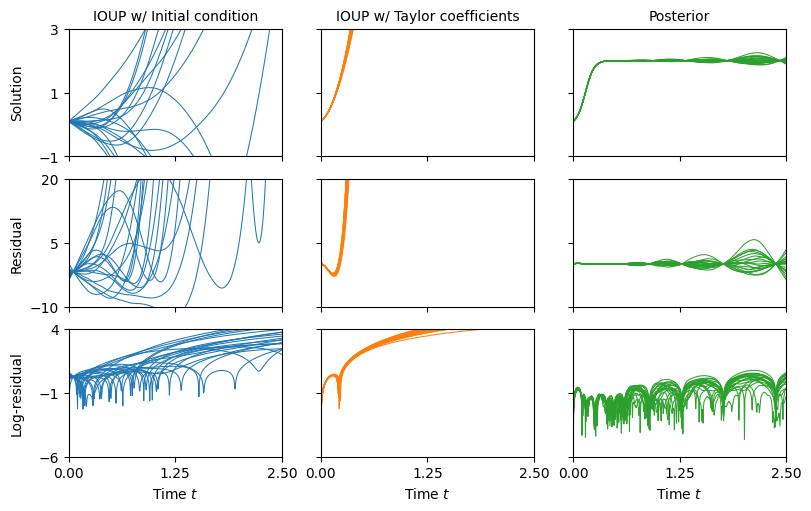

In [5]:
fig, (axes_state, axes_residual, axes_log_abs) = plt.subplots(
    nrows=3, ncols=3, sharex=True, sharey="row", constrained_layout=True, figsize=(8, 5)
)
axes_state[0].set_title("IOUP w/ Initial condition", fontsize="medium")
axes_state[1].set_title("IOUP w/ Taylor coefficients", fontsize="medium")
axes_state[2].set_title("Posterior", fontsize="medium")

sample_style = {"marker": "None", "alpha": 0.99, "linewidth": 0.75}


def residual(x, t):
    """Evaluate the ODE residual."""
    vf_wrapped = functools.partial(vector_field, t=t)
    return x[1] - jax.vmap(jax.vmap(vf_wrapped))(x[0])


residual_prior = residual(samples_prior, ts)
residual_tcoeffs = residual(samples_tcoeffs, ts)
residual_posterior = residual(samples_posterior, ts)


for i in range(num_samples):
    # Plot all state-samples
    axes_state[0].plot(ts, samples_prior[0][i, ...], **sample_style, color="C0")
    axes_state[1].plot(ts, samples_tcoeffs[0][i, ...], **sample_style, color="C1")
    axes_state[2].plot(ts, samples_posterior[0][i, ...], **sample_style, color="C2")

    # Plot all residual-samples
    axes_residual[0].plot(ts, residual_prior[i, ...], **sample_style, color="C0")
    axes_residual[1].plot(ts, residual_tcoeffs[i, ...], **sample_style, color="C1")
    axes_residual[2].plot(ts, residual_posterior[i, ...], **sample_style, color="C2")

    # Plot all log-residual samples
    axes_log_abs[0].plot(
        ts, jnp.log10(jnp.abs(residual_prior))[i, ...], **sample_style, color="C0"
    )
    axes_log_abs[1].plot(
        ts, jnp.log10(jnp.abs(residual_tcoeffs))[i, ...], **sample_style, color="C1"
    )
    axes_log_abs[2].plot(
        ts, jnp.log10(jnp.abs(residual_posterior))[i, ...], **sample_style, color="C2"
    )


# Set the x- and y-ticks/limits
axes_state[0].set_xticks((t0, (t0 + t1) / 2, t1))
axes_state[0].set_xlim((t0, t1))

axes_state[0].set_ylim((-1, 3))
axes_state[0].set_yticks((-1, 1, 3))

axes_residual[0].set_ylim((-10.0, 20))
axes_residual[0].set_yticks((-10.0, 5, 20))

axes_log_abs[0].set_ylim((-6, 4))
axes_log_abs[0].set_yticks((-6, -1, 4))

# Label the x- and y-axes
axes_state[0].set_ylabel("Solution", fontsize="medium")
axes_residual[0].set_ylabel("Residual", fontsize="medium")
axes_log_abs[0].set_ylabel("Log-residual", fontsize="medium")
axes_log_abs[0].set_xlabel("Time $t$", fontsize="medium")
axes_log_abs[1].set_xlabel("Time $t$", fontsize="medium")
axes_log_abs[2].set_xlabel("Time $t$", fontsize="medium")

# Show the result
fig.align_ylabels()
plt.show()